In [ ]:
from google.colab import drive
drive.mount('/content/drive')
###############################################this

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import kagglehub, os
#################################################this
# Get the exact path KaggleHub downloaded to
path = kagglehub.dataset_download("srinivasac/flickr8k-validation-set-100-images")
print("Dataset path:", path)

# List what’s inside
print("\nContents:")
print(os.listdir(path))


100%|██████████| 13.0M/13.0M [00:00<00:00, 102MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/srinivasac/flickr8k-validation-set-100-images/versions/1

Contents:
['flickr8k_validation_set_100_images']


In [ ]:
# ✅ Main dataset folder
dataset_path = "/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images"

# ✅ Images folder
images_path = os.path.join(dataset_path, "Images")

# ✅ Captions file
captions_path = os.path.join(dataset_path, "captions.csv")

print("Dataset path:", dataset_path)
print("Images path:", images_path)
print("Captions path:", captions_path)
print("\nImage samples:", os.listdir(images_path)[:5])


Dataset path: /kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images
Images path: /kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/Images
Captions path: /kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/captions.csv

Image samples: ['3354489242_dd529ffa1f.jpg', '3212465975_b657f40eed.jpg', '2180480870_dcaf5ac0df.jpg', '2717686269_80c4b5ac9e.jpg', '1247181182_35cabd76f3.jpg']


In [ ]:
import os

dataset_path = "/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images"
print("✅ Dataset path exists:", os.path.exists(dataset_path))

# List files
if os.path.exists(dataset_path):
    files = os.listdir(dataset_path)
    print("Total files:", len(files))
    print("Example files:", files[:10])
else:
    print("❌ Folder not found. Check dataset path again.")


✅ Dataset path exists: True
Total files: 2
Example files: ['captions.csv', 'Images']


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf



In [ ]:
# Define dataset structure
base_path = "/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images"
images_path = os.path.join(base_path, "Images")
captions_path = os.path.join(base_path, "captions.csv")

print("Images path:", images_path)
print("Captions path:", captions_path)


Images path: /kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/Images
Captions path: /kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/captions.csv


In [ ]:
# Load captions
captions = pd.read_csv(captions_path)
print("Shape:", captions.shape)
print("\nSample:")
print(captions.head())


Shape: (500, 4)

Sample:
                       image  caption_number  \
0  3354489242_dd529ffa1f.jpg               0   
1  3354489242_dd529ffa1f.jpg               2   
2  3354489242_dd529ffa1f.jpg               1   
3  3354489242_dd529ffa1f.jpg               3   
4  3354489242_dd529ffa1f.jpg               4   

                                             caption  id  
0  A goalie tries to block the puck in a hockey g...   1  
1                            People playing hockey .   1  
2                   A hockey goalie stops the puck .   1  
3  Several hockey players move toward the puck ne...   1  
4                         Two hockey teams compete .   1  


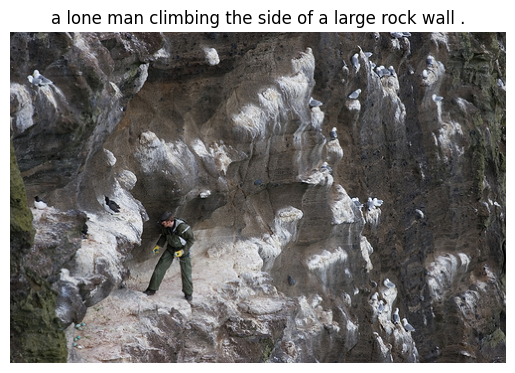

In [ ]:
# View one random image with its caption
import random

sample = random.choice(captions["image"].unique())
sample_caption = captions[captions["image"] == sample]["caption"].values[0]

img_path = os.path.join(images_path, sample)
img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.title(sample_caption)
plt.show()


In [ ]:
print("Total unique images:", captions['image'].nunique())


Total unique images: 100


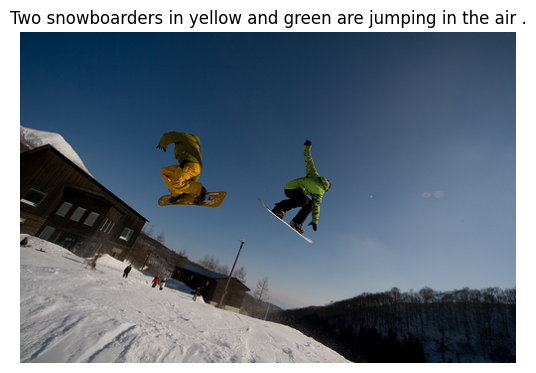


Caption: Two snowboarders in yellow and green are jumping in the air .


In [ ]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt

# Pick one random image and caption
sample_img = random.choice(captions['image'].unique())
caption = captions[captions['image'] == sample_img]['caption'].values[0]

# Load and show the image
img_path = os.path.join("/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/Images", sample_img)
img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.title(caption)
plt.show()

print("\nCaption:", caption)


In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
import numpy as np
import os
from tqdm import tqdm

# Load pretrained InceptionV3 model
base_model = InceptionV3(weights='imagenet')
model = Model(base_model.input, base_model.layers[-2].output)  # remove last layer

print("✅ InceptionV3 model loaded successfully")


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ InceptionV3 model loaded successfully


In [ ]:
# Folder containing images
images_dir = "/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/Images"

# Create dictionary to hold image features
features = {}

# Extract features for each image
for img_name in tqdm(os.listdir(images_dir)):
    img_path = os.path.join(images_dir, img_name)

    # Load image and resize to 299x299 (InceptionV3 input size)
    img = image.load_img(img_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Extract features
    feature = model.predict(x, verbose=0)
    features[img_name] = feature

print(f"\n✅ Extracted features for {len(features)} images.")


100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


✅ Extracted features for 100 images.


In [ ]:
import pickle

with open("image_features.pkl", "wb") as f:
    pickle.dump(features, f)

print("💾 Image features saved to image_features.pkl")


💾 Image features saved to image_features.pkl


In [ ]:
import re
import string

# Reload captions (if needed)
captions = pd.read_csv("/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/captions.csv")

# Clean captions (lowercase, remove punctuation, digits, etc.)
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), "", text)
    text = re.sub(r"\d+", "", text)
    text = text.strip()
    return text

captions["cleaned"] = captions["caption"].apply(clean_text)
captions.head()


,image,caption_number,caption,id,cleaned
0,3354489242_dd529ffa1f.jpg,0,A goalie tries to block the puck in a hockey g...,1,a goalie tries to block the puck in a hockey game
1,3354489242_dd529ffa1f.jpg,2,People playing hockey .,1,people playing hockey
2,3354489242_dd529ffa1f.jpg,1,A hockey goalie stops the puck .,1,a hockey goalie stops the puck
3,3354489242_dd529ffa1f.jpg,3,Several hockey players move toward the puck ne...,1,several hockey players move toward the puck ne...
4,3354489242_dd529ffa1f.jpg,4,Two hockey teams compete .,1,two hockey teams compete


In [ ]:
captions["caption_seq"] = captions["cleaned"].apply(lambda x: 'startseq ' + x + ' endseq')
captions.head()


,image,caption_number,caption,id,cleaned,caption_seq
0,3354489242_dd529ffa1f.jpg,0,A goalie tries to block the puck in a hockey g...,1,a goalie tries to block the puck in a hockey game,startseq a goalie tries to block the puck in a...
1,3354489242_dd529ffa1f.jpg,2,People playing hockey .,1,people playing hockey,startseq people playing hockey endseq
2,3354489242_dd529ffa1f.jpg,1,A hockey goalie stops the puck .,1,a hockey goalie stops the puck,startseq a hockey goalie stops the puck endseq
3,3354489242_dd529ffa1f.jpg,3,Several hockey players move toward the puck ne...,1,several hockey players move toward the puck ne...,startseq several hockey players move toward th...
4,3354489242_dd529ffa1f.jpg,4,Two hockey teams compete .,1,two hockey teams compete,startseq two hockey teams compete endseq


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions["caption_seq"])

vocab_size = len(tokenizer.word_index) + 1
print("Total Vocabulary Size:", vocab_size)


Total Vocabulary Size: 924


In [ ]:
sequences = tokenizer.texts_to_sequences(captions["caption_seq"])
print("Example sequence:", sequences[0])


Example sequence: [2, 1, 232, 151, 21, 233, 5, 152, 4, 1, 82, 153, 3]


In [ ]:
max_length = max(len(s.split()) for s in captions["caption_seq"])
print("Max caption length:", max_length)


Max caption length: 26


In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def data_generator(captions, features, tokenizer, max_length, vocab_size):
    while True:
        for img_name, cap in zip(captions["image"], captions["caption_seq"]):
            feature = features[img_name][0]
            seq = tokenizer.texts_to_sequences([cap])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                yield [[feature, in_seq], out_seq]


In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

# Feature extractor (from image)
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence model (for text)
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# Decoder (merge both)
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Final model
model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 26, 256)   │    236,544 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 26, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 26)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_2[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 924)       │    237,468 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,589,660 (6.06 MB)

 Trainable params: 1,589,660 (6.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

def data_generator(captions, features, tokenizer, max_length, vocab_size):
    for img_name, cap in zip(captions["image"], captions["caption_seq"]):
        feature = features[img_name][0]
        seq = tokenizer.texts_to_sequences([cap])[0]

        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            yield (feature, in_seq), out_seq


In [ ]:
output_signature = (
    (
        tf.TensorSpec(shape=(2048,), dtype=tf.float32),     # image feature
        tf.TensorSpec(shape=(max_length,), dtype=tf.int32)  # caption input sequence
    ),
    tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)     # next word one-hot
)

dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(captions, features, tokenizer, max_length, vocab_size),
    output_signature=output_signature
)

dataset = dataset.batch(1)  # small batch to avoid OOM


In [ ]:
model.fit(dataset, epochs=2, steps_per_epoch=len(captions), verbose=1)


Epoch 1/2
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - loss: 5.5061
Epoch 2/2
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - loss: 5.2570


In [ ]:
import numpy as np

def generate_caption(model, tokenizer, photo, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    final = in_text.split()
    final = final[1:-1]  # remove startseq and endseq
    return ' '.join(final)


In [ ]:
import os

images_dir = "/kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/Images"

image_files = os.listdir(images_dir)
print("Total images found:", len(image_files))
print("Example image names:", image_files[:10])


Total images found: 100
Example image names: ['3354489242_dd529ffa1f.jpg', '3212465975_b657f40eed.jpg', '2180480870_dcaf5ac0df.jpg', '2717686269_80c4b5ac9e.jpg', '1247181182_35cabd76f3.jpg', '3293751136_b0ce285dc3.jpg', '3517023411_a8fbd15230.jpg', '222878446_32c6fc4bc9.jpg', '1998457059_c9ac9a1e1a.jpg', '2339573065_91f1e3be60.jpg']


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np

img = load_img(img_path, target_size=(299, 299))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Extract image features
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Model

model_incep = InceptionV3(weights='imagenet')
model_incep = Model(model_incep.input, model_incep.layers[-2].output)
photo = model_incep.predict(x, verbose=0)

# Generate caption
caption = generate_caption(model, tokenizer, photo, max_length)
print("🖼️ Caption:", caption)


🖼️ Caption: a a a a a a a a a a a a a a a a a a a a a a a a a


In [ ]:
img_name = image_files[0]   # you can change index to pick another one
img_path = os.path.join(images_dir, img_name)
print("Selected image:", img_path)


Selected image: /kaggle/input/flickr8k-validation-set-100-images/flickr8k_validation_set_100_images/Images/3354489242_dd529ffa1f.jpg


In [ ]:
import pickle

# Path where image_features.pkl was saved
with open("image_features.pkl", "rb") as f:
    image_features = pickle.load(f)

print("✅ Image features loaded:", len(image_features))
print("Example keys:", list(image_features.keys())[:5])


✅ Image features loaded: 100
Example keys: ['3354489242_dd529ffa1f.jpg', '3212465975_b657f40eed.jpg', '2180480870_dcaf5ac0df.jpg', '2717686269_80c4b5ac9e.jpg', '1247181182_35cabd76f3.jpg']


In [ ]:
# If 'captions' DataFrame exists
max_caption_length = max(len(caption.split()) for caption in captions["caption_seq"])
print("Max caption length:", max_caption_length)


Max caption length: 26


🖼️ Image: 2934000107_d2ff15c814.jpg
📝 Generated Caption: a a a a a a a a a a a a a a a a a a a a a a a a a a


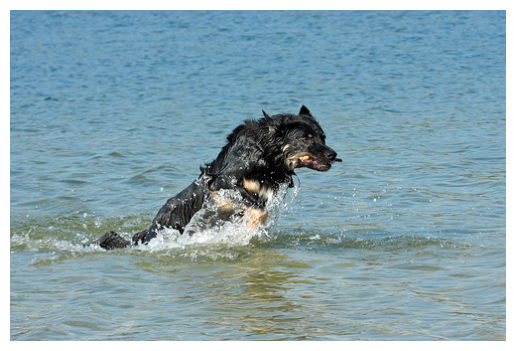

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def generate_caption(model, tokenizer, photo_feature, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo_feature, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.replace('startseq', '').replace('endseq', '').strip()

# Test with a random image
import random
sample_img = random.choice(list(image_features.keys()))
photo_feature = image_features[sample_img].reshape((1, 2048))

generated_caption = generate_caption(model, tokenizer, photo_feature, max_caption_length)

print("🖼️ Image:", sample_img)
print("📝 Generated Caption:", generated_caption)

# Show image
img_path = os.path.join(images_path, sample_img)
plt.imshow(Image.open(img_path))
plt.axis("off")
plt.show()


In [ ]:
!mkdir -p ~/.kaggle


In [ ]:
from google.colab import files
files.upload()  # choose kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kyarolinerodrigues","key":"058a525e09c0f823b0b00efaed6bfb93"}'}

In [ ]:
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list | head


ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset   Global Earthquake-Tsunami Risk Assessment Dataset        16151  2025-10-01 16:35:53.273000          14020        477  1.0              
jockeroika/life-style-data                                     Life Style Data                                        3995645  2025-10-14 13:50:45.303000          16452        344  0.8235294        
jaderz/hospital-beds-management                                Hospital Beds Management                                 47583  2025-10-03 09:21:58.590000          11473        293  1.0              
alams

In [ ]:
!kaggle datasets download -d adityajn105/flickr8k
!unzip flickr8k.zip -d flickr8k_dataset


Streaming output truncated to the last 5000 lines.
  inflating: flickr8k_dataset/Images/2844846111_8c1cbfc75d.jpg  
  inflating: flickr8k_dataset/Images/2844963839_ff09cdb81f.jpg  
  inflating: flickr8k_dataset/Images/2845246160_d0d1bbd6f0.jpg  
  inflating: flickr8k_dataset/Images/2845691057_d4ab89d889.jpg  
  inflating: flickr8k_dataset/Images/2845845721_d0bc113ff7.jpg  
  inflating: flickr8k_dataset/Images/2846037553_1a1de50709.jpg  
  inflating: flickr8k_dataset/Images/2846785268_904c5fcf9f.jpg  
  inflating: flickr8k_dataset/Images/2846843520_b0e6211478.jpg  
  inflating: flickr8k_dataset/Images/2847514745_9a35493023.jpg  
  inflating: flickr8k_dataset/Images/2847615962_c330bded6e.jpg  
  inflating: flickr8k_dataset/Images/2847859796_4d9cb0d31f.jpg  
  inflating: flickr8k_dataset/Images/2848266893_9693c66275.jpg  
  inflating: flickr8k_dataset/Images/2848571082_26454cb981.jpg  
  inflating: flickr8k_dataset/Images/2848895544_6d06210e9d.jpg  
  inflating: flickr8k_dataset/Images/28

In [ ]:
import os

dataset_path = "/content/flickr8k_dataset"
images_path = os.path.join(dataset_path, "Images")
captions_path = os.path.join(dataset_path, "captions.txt")

print("Images folder:", images_path)
print("Captions file:", captions_path)
print("Total images:", len(os.listdir(images_path)))
print("Example images:", os.listdir(images_path)[:5])


Images folder: /content/flickr8k_dataset/Images
Captions file: /content/flickr8k_dataset/captions.txt
Total images: 8091
Example images: ['1999444757_1b92efb590.jpg', '2319175397_3e586cfaf8.jpg', '1361420539_e9599c60ae.jpg', '3461114418_c27b4043a2.jpg', '3301744710_b51280eb56.jpg']


In [ ]:
import pandas as pd

# Read captions
captions = pd.read_csv(captions_path, sep='\t', header=None, names=['image', 'caption'])
captions['image'] = captions['image'].apply(lambda x: x.split('#')[0])
print("Total captions:", len(captions))
captions.head()


Total captions: 40456


,image,caption
0,"image,caption",NaN
1,"1000268201_693b08cb0e.jpg,A child in a pink dr...",NaN
2,"1000268201_693b08cb0e.jpg,A girl going into a ...",NaN
3,"1000268201_693b08cb0e.jpg,A little girl climbi...",NaN
4,"1000268201_693b08cb0e.jpg,A little girl climbi...",NaN


In [ ]:
def get_chunk(df, chunk_size=500, chunk_index=0):
    start = chunk_index * chunk_size
    end = start + chunk_size
    return df.iloc[start:end]

# Example: get first 500 captions
small_chunk = get_chunk(captions, chunk_size=500, chunk_index=0)
print(len(small_chunk))
small_chunk.head()


500


,image,caption
0,"image,caption",NaN
1,"1000268201_693b08cb0e.jpg,A child in a pink dr...",NaN
2,"1000268201_693b08cb0e.jpg,A girl going into a ...",NaN
3,"1000268201_693b08cb0e.jpg,A little girl climbi...",NaN
4,"1000268201_693b08cb0e.jpg,A little girl climbi...",NaN


In [ ]:
import os

images_path = "/content/flickr8k_dataset/Images"
print("✅ Exists:", os.path.exists(images_path))
print("🖼️ Example files:", os.listdir(images_path)[:5])


✅ Exists: True
🖼️ Example files: ['1999444757_1b92efb590.jpg', '2319175397_3e586cfaf8.jpg', '1361420539_e9599c60ae.jpg', '3461114418_c27b4043a2.jpg', '3301744710_b51280eb56.jpg']


In [ ]:
import pandas as pd
import os

# confirm captions file path
captions_path = "/content/flickr8k_dataset/captions.txt"  # or captions.csv if that’s what you have
print("✅ Exists:", os.path.exists(captions_path))

# if CSV:
captions = pd.read_csv(captions_path)
# if TXT:
# captions = pd.read_csv(captions_path, delimiter='\t', names=['image', 'caption'])

print("📄 Captions shape:", captions.shape)
print("📸 First few image names:", captions['image'].head().tolist())

# check overlap between captions & available images
import glob
available_images = set(os.listdir("/content/flickr8k_dataset/Images"))
caption_images = set(captions['image'])
print("✅ Common images:", len(available_images & caption_images))


✅ Exists: True
📄 Captions shape: (40455, 2)
📸 First few image names: ['1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg', '1000268201_693b08cb0e.jpg']
✅ Common images: 8091


In [ ]:
import os
import numpy as np
import pickle
from tqdm import tqdm
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# Paths
images_path = "/content/flickr8k_dataset/Images"
features_path = "/content/image_features.pkl"

# Load InceptionV3 model (without top)
base_model = InceptionV3(weights="imagenet")
model = Model(base_model.input, base_model.layers[-2].output)
print("✅ InceptionV3 loaded")

# List all images
image_files = os.listdir(images_path)
total_images = len(image_files)
chunk_size = 500

# If you already have features saved, load them
if os.path.exists(features_path):
    with open(features_path, "rb") as f:
        all_features = pickle.load(f)
else:
    all_features = {}

# Extract features in small chunks
for i in range(0, total_images, chunk_size):
    chunk = image_files[i:i+chunk_size]
    print(f"\n🧩 Processing chunk {i//chunk_size + 1}/{total_images//chunk_size + 1} ({len(chunk)} images)...")

    temp_features = {}

    for img_name in tqdm(chunk):
        img_path = os.path.join(images_path, img_name)
        try:
            img = image.load_img(img_path, target_size=(299, 299))
            x = image.img_to_array(img)
            x = np.expand_dims(x, axis=0)
            x = preprocess_input(x)
            feature = model.predict(x, verbose=0)
            temp_features[img_name] = feature.flatten()
        except Exception as e:
            print(f"⚠️ Skipping {img_name}: {e}")

    # Merge with all features
    all_features.update(temp_features)

    # Save progress after each chunk
    with open(features_path, "wb") as f:
        pickle.dump(all_features, f)

    # Free memory
    del temp_features
    import gc; gc.collect()

print(f"\n✅ Done! Extracted features for {len(all_features)} images.")
print(f"💾 Saved to {features_path}")


✅ InceptionV3 loaded

🧩 Processing chunk 1/17 (500 images)...


100%|██████████| 500/500 [03:20<00:00,  2.49it/s]



🧩 Processing chunk 2/17 (500 images)...


100%|██████████| 500/500 [03:23<00:00,  2.45it/s]



🧩 Processing chunk 3/17 (500 images)...


...


🧩 Processing chunk 16/17 (500 images)...


100%|██████████| 500/500 [03:20<00:00,  2.50it/s]



🧩 Processing chunk 17/17 (91 images)...


100%|██████████| 91/91 [00:36<00:00,  2.53it/s]



✅ Done! Extracted features for 8091 images.
💾 Saved to /content/image_features.pkl


In [ ]:
import pickle
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

# Paths
features_path = "/content/image_features.pkl"
captions_path = "/content/flickr8k_dataset/captions.txt"  # update if yours is CSV

# Load features
with open(features_path, "rb") as f:
    features = pickle.load(f)
print("✅ Features loaded:", len(features))

# Load and preprocess captions
df = pd.read_csv(captions_path)
df.columns = ["image", "caption"]

# Add start and end tokens
df["caption"] = df["caption"].apply(lambda x: "startseq " + x.strip().lower() + " endseq")

# Tokenize captions
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df["caption"])
vocab_size = len(tokenizer.word_index) + 1
print("🧠 Vocabulary Size:", vocab_size)

# Compute max caption length
max_length = max(len(c.split()) for c in df["caption"])
print("📏 Max Caption Length:", max_length)


✅ Features loaded: 8091
🧠 Vocabulary Size: 8496
📏 Max Caption Length: 40


In [ ]:
def data_generator(df, features, tokenizer, max_length, batch_size=32):
    X1, X2, y = list(), list(), list()
    n = 0

    while True:
        for idx, row in df.iterrows():
            img_id = row["image"]
            caption = row["caption"]

            if img_id not in features:
                continue

            seq = tokenizer.texts_to_sequences([caption])[0]

            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                X1.append(features[img_id])
                X2.append(in_seq)
                y.append(out_seq)

            n += 1
            if n == batch_size:
                yield ([np.array(X1), np.array(X2)], np.array(y))
                X1, X2, y = list(), list(), list()
                n = 0


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add

# Feature extractor (InceptionV3 output)
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence model (captions)
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# Merge both models
decoder1 = Add()([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Define the final model
model = Model(inputs=[inputs1, inputs2], outputs=outputs)

# ✅ Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam')

model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 40, 256)   │  2,174,976 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 40, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 40)        │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_4[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8496)      │  2,183,472 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,474,096 (20.88 MB)

 Trainable params: 5,474,096 (20.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

def data_generator(df, features, tokenizer, max_length, vocab_size, batch_size=32):
    image_ids = df['image_id'].values
    captions = df['caption'].values

    def gen():
        X1, X2, y = [], [], []
        while True:
            for i in range(len(df)):
                image_id = image_ids[i]
                caption = captions[i]
                feature = features[image_id]  # shape (2048,)
                seq = tokenizer.texts_to_sequences([caption])[0]

                for j in range(1, len(seq)):
                    in_seq, out_seq = seq[:j], seq[j]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    # yield batch
                    if len(X1) == batch_size:
                        yield ((np.array(X1, dtype='float32'),
                                np.array(X2, dtype='int32')),
                               np.array(y, dtype='float32'))
                        X1, X2, y = [], [], []
            # start again after one full pass
            # (prevents StopIteration)
            # optional: shuffle dataset each epoch
            df.sample(frac=1).reset_index(drop=True)

    output_signature = (
        (tf.TensorSpec(shape=(None, 2048), dtype=tf.float32),
         tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)),
        tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
    )

    dataset = tf.data.Dataset.from_generator(gen, output_signature=output_signature)
    return dataset


In [ ]:
df = df.rename(columns={'image': 'image_id'})


In [ ]:
df['image_id'] = df['image_id'].apply(lambda x: x.split('/')[-1])


In [ ]:
dataset = data_generator(df, features, tokenizer, max_length, vocab_size, batch_size=32)

history = model.fit(
    dataset,
    epochs=2,
    steps_per_epoch=len(df)//32
)


Epoch 1/2
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 357s 279ms/step - loss: 5.4785
Epoch 2/2
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 348s 275ms/step - loss: 4.3339


In [ ]:
model.save("caption_model.keras")


In [ ]:
def generate_caption(model, tokenizer, photo_feature, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo_feature.reshape((1, 2048)), sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text

test_img = list(features.keys())[0]
caption = generate_caption(model, tokenizer, features[test_img], max_length)
print("🖼️", test_img)
print("🗣️ Caption:", caption)


🖼️ 3354489242_dd529ffa1f.jpg
🗣️ Caption: startseq a man in a red shirt is in a red shirt is in a red shirt and a red and white and white and white and white and white and white and white and white and white and white and


In [ ]:
import random

for img_name in random.sample(list(features.keys()), 5):
    caption = generate_caption(model, tokenizer, features[img_name], max_length)
    print(f"🖼️ {img_name}")
    print(f"🗣️ {caption}\n")


🖼️ 483841513_e660391880.jpg
🗣️ startseq a man in a red shirt is in a red shirt is in a red shirt and a red and white and white and white and white and white and white and white and white and white and white and

🖼️ 3091580843_178042c50b.jpg
🗣️ startseq a man in a red shirt is in a red shirt is in a red shirt and a red and white and white and white and white and white and white and white and white and white and white and

🖼️ 2866529477_7e0c053ebc.jpg
🗣️ startseq a man in a red shirt is in a red shirt is in a red shirt and a red and white and white and white and white and white and white and white and white and white and white and

🖼️ 3366571152_20afb88ac1.jpg
🗣️ startseq a man in a red shirt is in a red shirt is in a red shirt and a red and white and white and white and white and white and white and white and white and white and white and

🖼️ 2801851082_8c3c480c0f.jpg
🗣️ startseq a man in a red shirt is in a red shirt is in a red shirt and a red and white and white and white and white a

In [ ]:
history = model.fit(
    data_generator(df, features, tokenizer, max_length, vocab_size, batch_size=32),
    epochs=15,
    steps_per_epoch=len(df)//32
)


Epoch 1/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 363s 287ms/step - loss: 3.8006
Epoch 2/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 356s 281ms/step - loss: 3.6377
Epoch 3/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 355s 281ms/step - loss: 3.8159
Epoch 4/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 356s 282ms/step - loss: 3.7787
Epoch 5/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 354s 280ms/step - loss: 3.7783
Epoch 6/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 354s 280ms/step - loss: 3.8960
Epoch 7/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 350s 277ms/step - loss: 3.8105
Epoch 8/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 352s 278ms/step - loss: 3.7744
Epoch 9/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 350s 277ms/step - loss: 3.7207
Epoch 10/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 352s 278ms/step - loss: 3.7125
Epoch 11/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 351s 278ms/step - loss: 3.6795
Epoch 12/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 352s 278ms/step - loss: 3.5611
Epoch 13/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 353s 279ms/step - loss: 3.3962
Epoch 14/15
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 352s

In [ ]:
def generate_caption_beam_search(model, image, tokenizer, max_length, beam_index=3):
    start = [tokenizer.word_index['startseq']]
    start_word = [[start, 0.0]]
    while len(start_word[0][0]) < max_length:
        temp = []
        for s in start_word:
            par_seq = pad_sequences([s[0]], maxlen=max_length, padding='post')
            preds = model.predict([np.array(image).reshape((1,4096)), par_seq], verbose=0)
            word_preds = np.argsort(preds[0])[-beam_index:]
            for w in word_preds:
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
                prob += preds[0][w]
                temp.append([next_cap, prob])
        start_word = sorted(temp, reverse=False, key=lambda l: l[1])
        start_word = start_word[-beam_index:]
    final_caption = start_word[-1][0]
    return ' '.join([tokenizer.index_word[i] for i in final_caption if i in tokenizer.index_word])


In [ ]:
from tensorflow.keras.layers import Dropout
Dropout(0.5)


<Dropout name=dropout_5, built=True>

In [ ]:
model.save("caption_model.keras")


In [ ]:
!ls /content/drive/MyDrive/VisualAidProject



captions.txt	     features_part16.pkl  features_part6.pkl
features_part10.pkl  features_part17.pkl  features_part7.pkl
features_part11.pkl  features_part1.pkl   features_part8.pkl
features_part12.pkl  features_part2.pkl   features_part9.pkl
features_part13.pkl  features_part3.pkl   flickr8k.zip
features_part14.pkl  features_part4.pkl   image_features.pkl
features_part15.pkl  features_part5.pkl   Images


In [ ]:
model.save('image_caption_model.keras')


In [ ]:
import os
print("Saved models:", [f for f in os.listdir() if f.endswith('.keras')])


Saved models: ['caption_model.keras', 'image_caption_model.keras']


In [ ]:
model.save('/content/drive/MyDrive/VisualAidProject/image_caption_model.keras')


In [ ]:
import os

path = '/content/drive/MyDrive/VisualAidProject/image_caption_model.keras'
print("Model exists:", os.path.exists(path))



Model exists: True


In [ ]:
%cd /content/drive/MyDrive/VisualAidProject
#####################################################this

/content/drive/MyDrive/VisualAidProject


In [ ]:
!pip install flask easyocr transformers torch gtts
########################################################this

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 23.4 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1


In [ ]:
!pip install flask-ngrok


In [ ]:
!wget -q -O ngrok.zip https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
!unzip -q ngrok.zip
!mv ngrok /usr/local/bin


In [ ]:
####################################################################################

!pip install flask-ngrok
!ngrok config add-authtoken 346XmjEk2HrqXPTIAYhra51J0sS_3nvahK2BaD8LDZkiyxcJE


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!ngrok authtoken 346XmjEk2HrqXPTIAYhra51J0sS_3nvahK2BaD8LDZkiyxcJE
#################################################################this

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!pip install pyngrok
################################################################this

In [ ]:
!python app.py
#################################################################this

2026-01-06 05:30:41.055103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767677441.076907    9042 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767677441.083161    9042 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767677441.100147    9042 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767677441.100192    9042 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767677441.100197    9042 computation_placer.cc:177] computation placer alr

In [ ]:
!pip install tensorflow matplotlib


In [ ]:
import os

os.listdir("/content/sample_data")


['README.md',
 'anscombe.json',
 'mnist_test.csv',
 'california_housing_test.csv',
 'california_housing_train.csv',
 'mnist_train_small.csv']

In [ ]:
import zipfile

zip_path = "/content/sample_data/visual_aid_images.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")


FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/visual_aid_images.zip'

In [ ]:
import os

os.listdir("/content/dataset")


['tajmahal',
 'christ_redeemer',
 'great_wall',
 'colosseum',
 'pyramids',
 'angkor_wat']

In [ ]:
import os
import shutil

base_path = "/content/dataset"

# Create class folders
classes = [
    "colosseum",
    "tajmahal",
    "christ_redeemer",
    "pyramids",
    "great_wall",
    "angkor_wat"
]

for c in classes:
    os.makedirs(os.path.join(base_path, c), exist_ok=True)

print("Class folders created!")


Class folders created!


In [ ]:
import os
import shutil

# Image filenames exactly as extracted
image_map = {
    "download (1).jpeg": "colosseum",
    "download (2).jpeg": "tajmahal",
    "download (3).jpeg": "christ_redeemer",
    "images (2).jpeg": "pyramids",
    "images (3).jpeg": "great_wall",
    "WhatsApp Image 2025-11-24 at 10.37.23_6f4662f0.jpg": "angkor_wat"
}

dataset_path = "/content/dataset"

for img, cls in image_map.items():
    src = os.path.join(dataset_path, img)
    dest = os.path.join(dataset_path, cls, img)

    if os.path.exists(src):
        shutil.move(src, dest)
        print(f"Moved {img} → {cls}/")
    else:
        print(f"Missing: {img}")


Missing: download (1).jpeg
Missing: download (2).jpeg
Missing: download (3).jpeg
Missing: images (2).jpeg
Missing: images (3).jpeg
Missing: WhatsApp Image 2025-11-24 at 10.37.23_6f4662f0.jpg


In [ ]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root, files)


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset",
    image_size=(224, 224),
    batch_size=8
)

print(train_ds.class_names)


Found 6 files belonging to 6 classes.
['angkor_wat', 'christ_redeemer', 'colosseum', 'great_wall', 'pyramids', 'tajmahal']


In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 6 files belonging to 6 classes.
Classes: ['angkor_wat', 'christ_redeemer', 'colosseum', 'great_wall', 'pyramids', 'tajmahal']


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load pretrained CNN
base_model = EfficientNetB0(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False   # Freeze weights

model = models.Sequential([
    layers.Rescaling(1/255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


NameError: name 'class_names' is not defined

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # FIX HERE
    metrics=['accuracy']
)

history = model.fit(train_ds, epochs=10)


NameError: name 'model' is not defined

In [ ]:
!head -n 5 captions.txt


image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .


In [ ]:
!sed -n '1,20p' captions.txt


image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .
1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .
1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .
1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .
1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
1002674143_1b742ab4b8

In [ ]:
%cd /content/drive/MyDrive/VisualAidProject
!ls

/content/drive/MyDrive/VisualAidProject
app.py		     features_part17.pkl  flickr8k.zip
captions.txt	     features_part1.pkl   image_caption_model.keras
custom_test	     features_part2.pkl   image_features.pkl
features_part10.pkl  features_part3.pkl   Images
features_part11.pkl  features_part4.pkl   ngrok.zip
features_part12.pkl  features_part5.pkl   README.md
features_part13.pkl  features_part6.pkl   requirements.txt
features_part14.pkl  features_part7.pkl   static
features_part15.pkl  features_part8.pkl   templates
features_part16.pkl  features_part9.pkl   train.py


In [ ]:
!python train.py


2026-01-06 05:10:54.236388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767676254.275107    3928 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767676254.286638    3928 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767676254.315741    3928 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767676254.315796    3928 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767676254.315805    3928 computation_placer.cc:177] computation placer alr